In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Gathering**
We begin by loading World Bank WDI data. This dataset contains socioeconomic indicators like GDP per capita, growth, life expectancy, school enrollment, poverty rate, Gini index, inflation, and unemployment for multiple countries from 2000–2023.

In [ ]:
# Load the Data
url = "https://raw.githubusercontent.com/khushi-analytics/world-development-analysis/main/data/processed/WDI_Data_2.csv"
df = pd.read_csv(url)

In [ ]:
# 3. Inspect data structure and sample
print(df.head())
print(df.info())

    Country Name                                        Series Name  \
0  United States                       GDP per capita (current US$)   
1  United States                              GDP growth (annual %)   
2  United States             School enrollment, secondary (% gross)   
3  United States            Life expectancy at birth, total (years)   
4  United States  Poverty headcount ratio at $3.00 a day (2021 P...   

  2000 [YR2000] 2001 [YR2001] 2002 [YR2002] 2003 [YR2003] 2004 [YR2004]  \
0   36329.97026    37133.6204   37997.74243   39490.30239    41724.6412   
1    4.07758576  0.9555383419   1.700447328   2.795605965   3.847771694   
2            ..            ..            ..            ..            ..   
3   76.63658537   76.83658537   76.93658537   77.03658537   77.48780488   
4           0.7             1             1             1             1   

  2005 [YR2005] 2006 [YR2006] 2007 [YR2007]  ... 2014 [YR2014] 2015 [YR2015]  \
0   44123.39965   46301.98765   48050.2274

# Data Cleaning & Missing Value Handling
We forward- and backward-fill time-series missing values per country. Any remaining gaps are replaced with the country median. This preserves trends while ensuring no data is lost for ML or EDA.

In [ ]:
# Remove [YR2000] etc.
df.columns = (
    df.columns
      .str.replace(r"\s*\[YR\d+\]", "", regex=True)
      .str.replace(" ", "_")
)

df.head()

,Country_Name,Series_Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,United States,GDP per capita (current US$),36329.97026,37133.6204,37997.74243,39490.30239,41724.6412,44123.39965,46301.98765,48050.22741,...,55153.39402,56849.46979,57976.6282,60047.71907,62875.66614,65227.95659,64401.50744,71307.40173,77860.91129,82304.62043
1,United States,GDP growth (annual %),4.07758576,0.9555383419,1.700447328,2.795605965,3.847771694,3.483549935,2.784539638,2.003858299,...,2.523819814,2.945550456,1.819451476,2.457622302,2.966505069,2.58382533,-2.163029139,6.055052933,2.51237532,2.887556009
2,United States,"School enrollment, secondary (% gross)",..,..,..,..,..,95.0524826,..,..,...,96.92453766,97.65254974,98.76992798,98.95233917,99.27558136,100.0634308,100.509819,101.1924896,97.47348785,..
3,United States,"Life expectancy at birth, total (years)",76.63658537,76.83658537,76.93658537,77.03658537,77.48780488,77.48780488,77.68780488,77.98780488,...,78.84146341,78.6902439,78.53902439,78.53902439,78.63902439,78.78780488,76.9804878,76.32926829,77.43414634,78.38536585
4,United States,Poverty headcount ratio at $3.00 a day (2021 P...,0.7,1,1,1,1,1,1,1,...,1.2,1.2,1.2,1.2,1,1,0.5,0.5,1.2,1.2


In [ ]:
# Convert Year Columns to Numeric
year_cols = [col for col in df.columns if col.isdigit()]

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
# Reshape from Wide to Long as this gives one row per country indicator year

df_long = df.melt(
    id_vars=["Country_Name", "Series_Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long.dropna(subset=["Value"], inplace=True)

df_long.head()

,Country_Name,Series_Name,Year,Value
0,United States,GDP per capita (current US$),2000,36329.970260
1,United States,GDP growth (annual %),2000,4.077586
3,United States,"Life expectancy at birth, total (years)",2000,76.636585
4,United States,Poverty headcount ratio at $3.00 a day (2021 P...,2000,0.700000
5,United States,Gini index,2000,40.100000


In [ ]:
# Pivot Indicators to Columns
df_pivot = df_long.pivot_table(
    index=["Country_Name", "Year"],
    columns="Series_Name",
    values="Value"
).reset_index()

df_pivot.columns = df_pivot.columns.str.replace(" ", "_").str.lower()
df_pivot.head()

Series_Name,country_name,year,gdp_growth_(annual_%),gdp_per_capita_(current_us$),gini_index,"inflation,_consumer_prices_(annual_%)","life_expectancy_at_birth,_total_(years)",poverty_headcount_ratio_at_$3.00_a_day_(2021_ppp)_(%_of_population),"school_enrollment,_secondary_(%_gross)","unemployment,_total_(%_of_total_labor_force)_(modeled_ilo_estimate)"
0,Brazil,2000,4.387949,3766.548115,NaN,7.044141,69.584,NaN,NaN,10.889
1,Brazil,2001,1.389896,3176.289357,58.4,6.840359,69.980,17.5,NaN,10.649
2,Brazil,2002,3.053462,2855.940189,58.1,8.450164,70.396,16.2,NaN,10.641
3,Brazil,2003,1.140829,3090.607010,57.6,14.714920,70.884,17.1,NaN,11.168
4,Brazil,2004,5.759965,3663.823188,56.5,6.597185,71.361,15.3,NaN,10.072


In [ ]:
# Rename Indicators for ML
df_pivot = df_pivot.rename(columns={
    "country_name": "country",
    "year": "year",
    "gdp_growth": "gdp_growth",
    "gdp_per_capita": "gdp_per_capita",
    "gini_index": "gini_index",
    "inflation,_consumer_prices_(annual_%)": "inflation",
    "life_expectancy": "life_expectancy",
    "poverty_rate": "poverty_rate",
    "school_enrollment": "school_enrollment",
    "unemployment,_total_(%_of_total_labor_force)_(modeled_ilo_estimate)": "unemployment"
})

df_pivot.head()

Series_Name,country,year,gdp_growth,gdp_per_capita,gini_index,inflation,life_expectancy,poverty_rate,school_enrollment,unemployment
0,Brazil,2000,4.387949,3766.548115,NaN,7.044141,69.584,NaN,NaN,10.889
1,Brazil,2001,1.389896,3176.289357,58.4,6.840359,69.980,17.5,NaN,10.649
2,Brazil,2002,3.053462,2855.940189,58.1,8.450164,70.396,16.2,NaN,10.641
3,Brazil,2003,1.140829,3090.607010,57.6,14.714920,70.884,17.1,NaN,11.168
4,Brazil,2004,5.759965,3663.823188,56.5,6.597185,71.361,15.3,NaN,10.072


In [ ]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            264 non-null    object 
 1   year               264 non-null    object 
 2   gdp_growth         264 non-null    float64
 3   gdp_per_capita     263 non-null    float64
 4   gini_index         132 non-null    float64
 5   inflation          242 non-null    float64
 6   life_expectancy    264 non-null    float64
 7   poverty_rate       132 non-null    float64
 8   school_enrollment  159 non-null    float64
 9   unemployment       264 non-null    float64
dtypes: float64(8), object(2)
memory usage: 20.8+ KB


Series_Name
poverty_rate         132
gini_index           132
school_enrollment    105
inflation             22
gdp_per_capita         1
country                0
year                   0
gdp_growth             0
life_expectancy        0
unemployment           0
dtype: int64


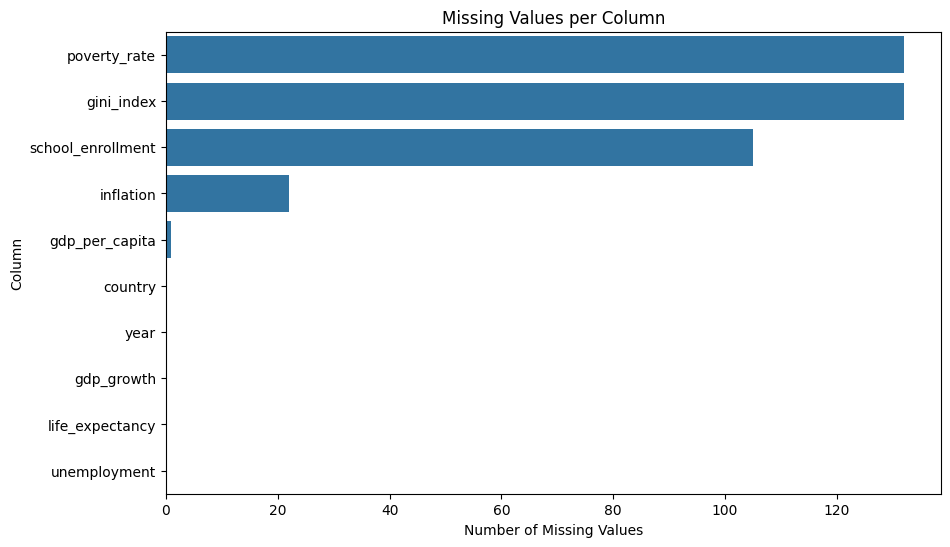

In [ ]:
# Visualize Missing Values

na_counts = df_pivot.isna().sum().sort_values(ascending=False)
print(na_counts)

plt.figure(figsize=(10,6))
sns.barplot(x=na_counts.values, y=na_counts.index)
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()

/tmp/ipython-input-4015817936.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_na = df_pivot.groupby("country").apply(lambda x: x.isna().sum().sum())


country
Brazil           17
China            29
Ethiopia         53
Germany           6
India            40
Japan            35
Nigeria          46
South Africa     39
Uganda           69
United States    13
Viet Nam         45
dtype: int64


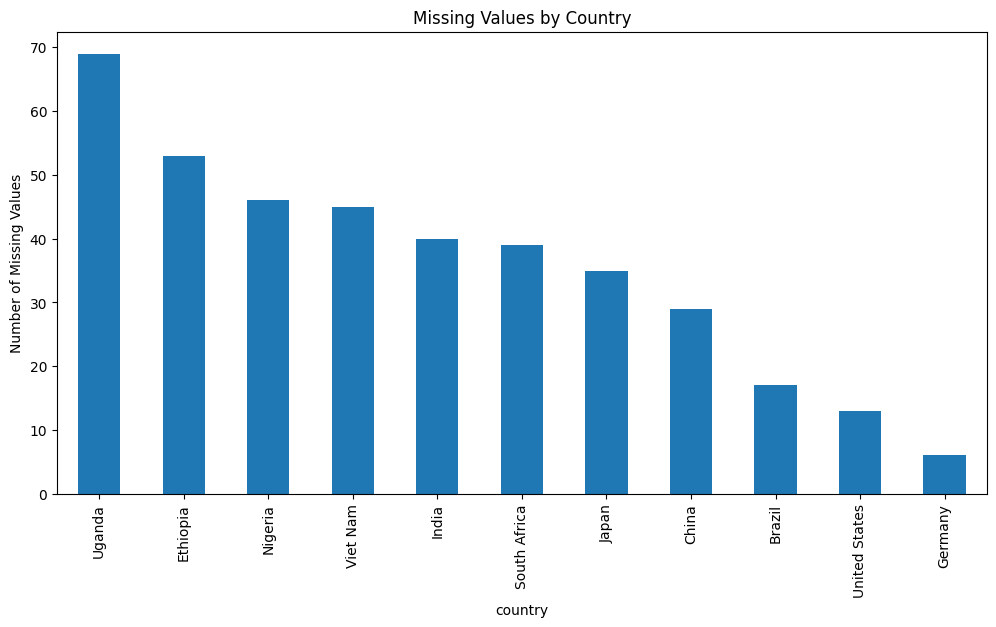

In [ ]:
# Total missing values per country
country_na = df_pivot.groupby("country").apply(lambda x: x.isna().sum().sum())
country_na.sort_values(ascending=False)
print(country_na)

plt.figure(figsize=(12,6))
country_na.sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values by Country")
plt.ylabel("Number of Missing Values")
plt.show()

In [ ]:
# Separate columns
non_numeric_cols = ['country', 'year']
numeric_cols = df_pivot.columns.difference(non_numeric_cols)

df_model = df_pivot.copy()

# Forward fill then backward fill per column within each country
for col in numeric_cols:
    df_model[col] = df_model.groupby('country')[col].transform(lambda x: x.ffill().bfill())

# Fill remaining NaNs with country-level median
for col in numeric_cols:
    df_model[col] = df_model.groupby('country')[col].transform(lambda x: x.fillna(x.median()))

# Check missing values
print(df_model.isna().sum())

Series_Name
country              0
year                 0
gdp_growth           0
gdp_per_capita       0
gini_index           0
inflation            0
life_expectancy      0
poverty_rate         0
school_enrollment    0
unemployment         0
dtype: int64


# Exploratory Data Analysis (EDA)

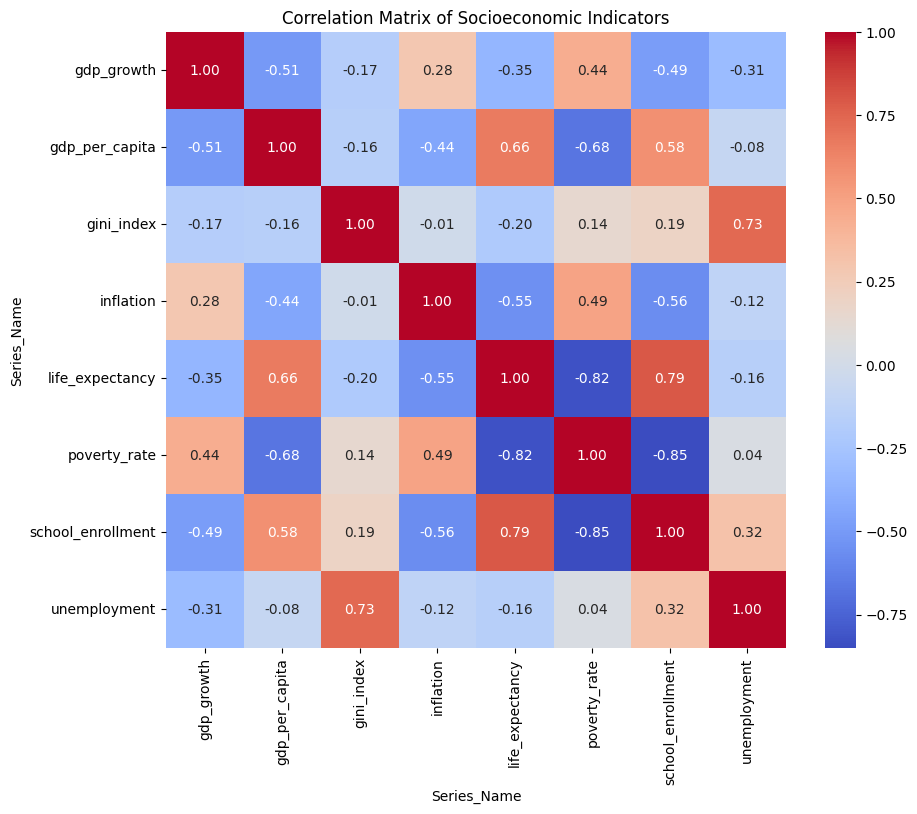

In [54]:
# Correlation Analysis
corr = df_model[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Socioeconomic Indicators")
plt.show()

Correlation matrix shows which indicators are most strongly associated with GDP per capita. Life expectancy, school enrollment, and poverty rate show strong correlations, while inflation and unemployment are less correlated.

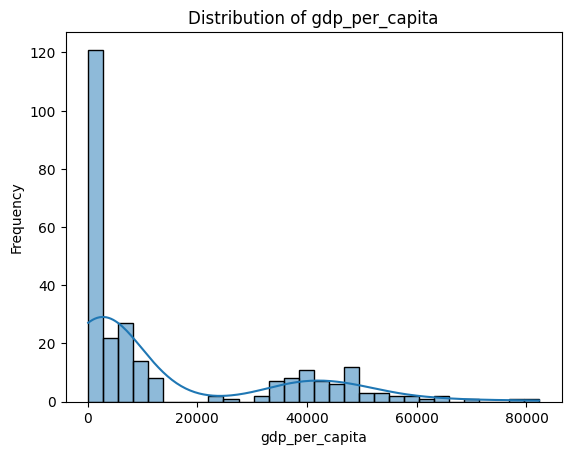

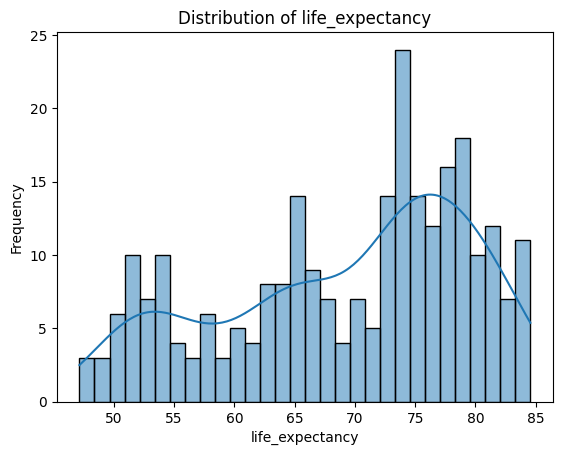

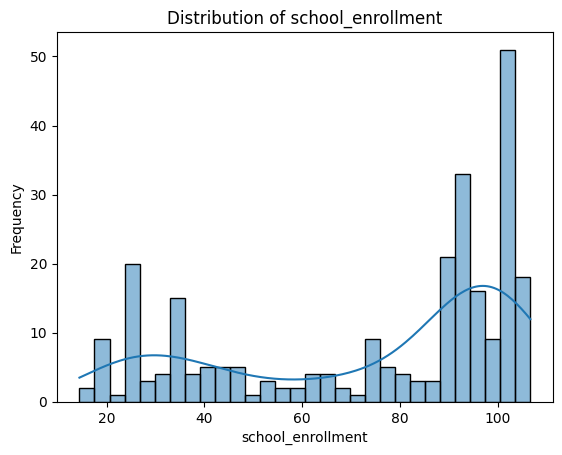

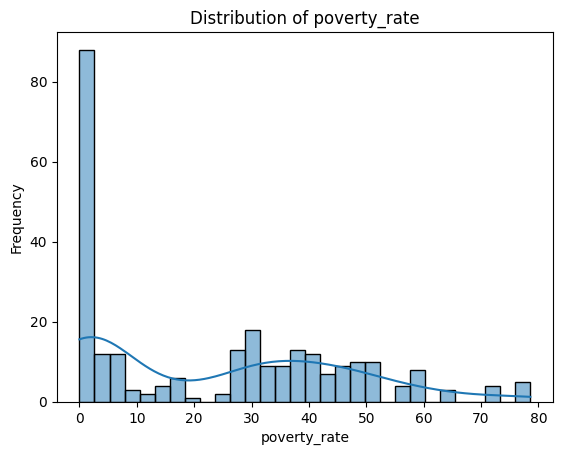

In [55]:
# Distribution of key indicators
indicators = ['gdp_per_capita','life_expectancy','school_enrollment','poverty_rate']

for ind in indicators:
    plt.figure()
    sns.histplot(df_model[ind], kde=True, bins=30)
    plt.title(f'Distribution of {ind}')
    plt.xlabel(ind)
    plt.ylabel("Frequency")
    plt.show()

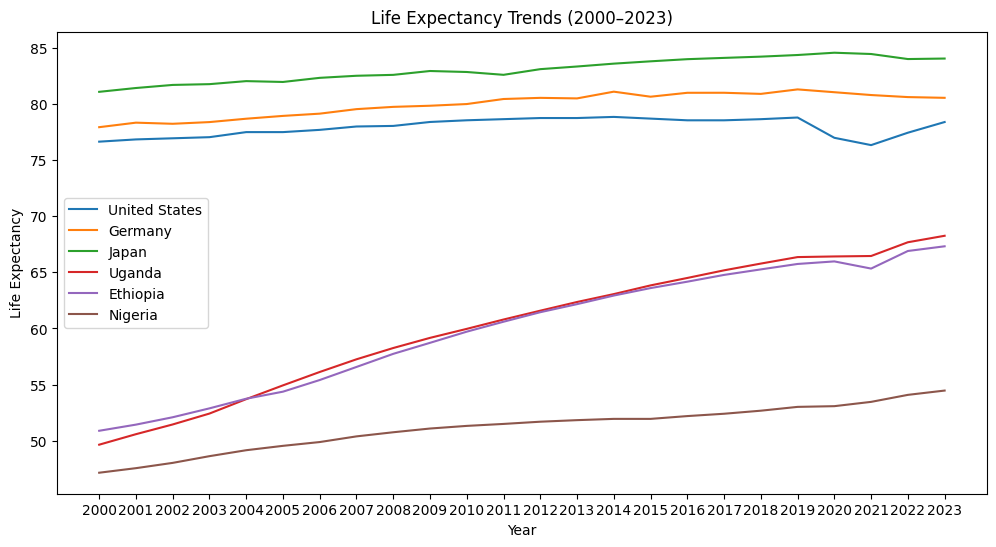

In [56]:
# Time-series trends: Life Expectancy by selected countries
high_income = ['United States','Germany','Japan']
low_income = ['Uganda','Ethiopia','Nigeria']

plt.figure(figsize=(12,6))
for country in high_income + low_income:
    subset = df_model[df_model['country']==country]
    plt.plot(subset['year'], subset['life_expectancy'], label=f"{country}")
plt.title("Life Expectancy Trends (2000–2023)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.show()

High-income countries show stable life expectancy. Low-income countries show notable improvement over time.

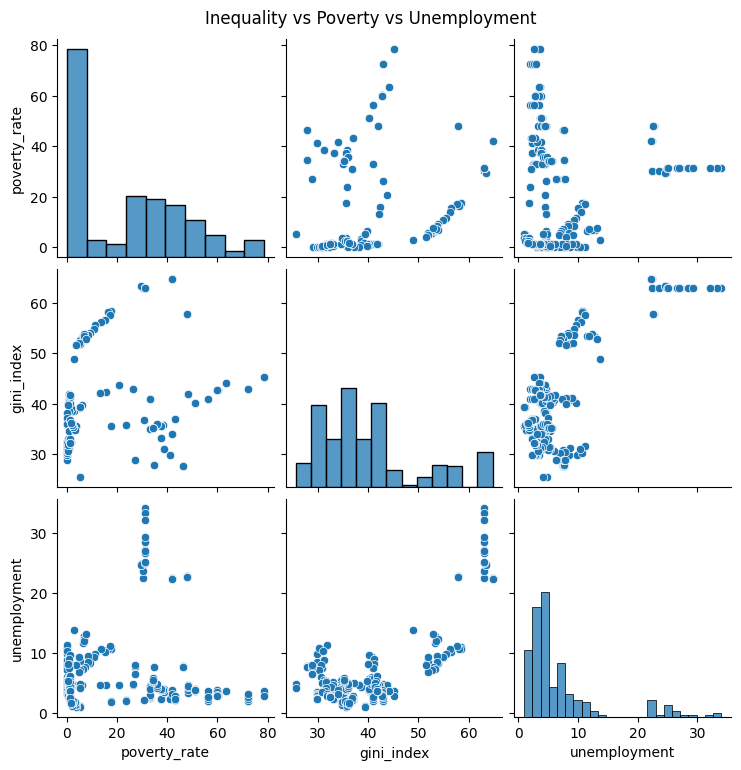

In [57]:
# Pairplot: Gini vs Poverty vs Unemployment
sns.pairplot(df_model, vars=['poverty_rate','gini_index','unemployment'], height=2.5)
plt.suptitle("Inequality vs Poverty vs Unemployment", y=1.02)
plt.show()

Moderate positive correlation between Gini index and poverty/unemployment. Highlights inequality patterns across countries.

# Prepare Data for Random Forest Modeling

In [58]:
# Target: GDP per capita
y = df_model['gdp_per_capita']

# Features: Other numeric indicators
features = ['gdp_growth','life_expectancy','school_enrollment','poverty_rate','gini_index','inflation','unemployment']
X = df_model[features]

# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 1374.49
R2 Score: 0.97


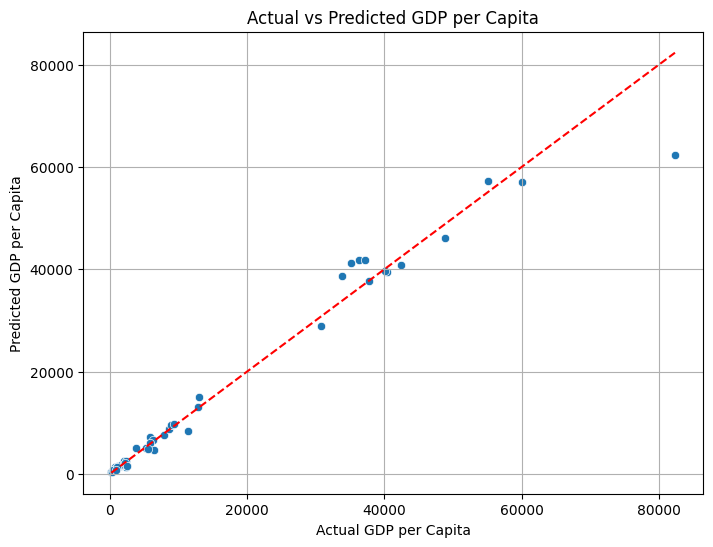

In [62]:
# Plot Actual vs Predicted GDP per Capita
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual GDP per Capita")
plt.ylabel("Predicted GDP per Capita")
plt.title("Actual vs Predicted GDP per Capita")
plt.grid(True)
plt.show()

R² shows how well the model explains variance in GDP per capita. MAE indicates average prediction error. Random Forest captures nonlinear interactions and feature importance.

# Feature Importance

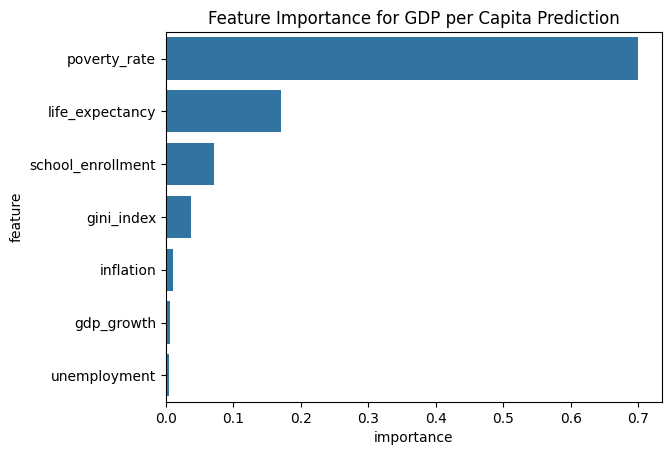

In [60]:
# Feature importance visualization
feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_importance)
plt.title("Feature Importance for GDP per Capita Prediction")
plt.show()

Poverty rate, life expectancy, and school enrollment  are most influential for GDP prediction. Inflation and unemployment have smaller impact.

# Predictive Scenario

In [61]:
# Predict GDP per capita for a scenario: improved social indicators
scenario = pd.DataFrame({
    'gdp_growth':[3],
    'life_expectancy':[70+5],  # increase 5 years
    'school_enrollment':[60+10],  # increase 10%
    'poverty_rate':[20-2],  # decrease 2%
    'gini_index':[35],
    'inflation':[2],
    'unemployment':[5]
})

predicted_gdp = rf.predict(scenario)
print(f"Predicted GDP per capita in scenario: ${predicted_gdp[0]:.2f}")

Predicted GDP per capita in scenario: $2649.91


By improving life expectancy and school enrollment while reducing poverty, the model predicts an increase in GDP per capita. This demonstrates how social development drives economic growth.